# Data Understanding and Initial Assessment

## Healthcare Infrastructure Gap Index (HIGI)

This notebook performs the initial assessment of the three datasets used in this study:
- National Family Health Survey (NFHS-5)
- Census of India 2011
- Rural Health Statistics (RHS)

The objective is to understand the structure, quality and suitability of the datasets before data cleaning and integration.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [8]:
# Google Drive Paths
RHS_PATH = "/content/drive/MyDrive/Healthcare-Infrastructure-Gap-Index/data/raw/RHS_Master.xlsx"
CENSUS_PATH = "/content/drive/MyDrive/Healthcare-Infrastructure-Gap-Index/data/raw/CensusData.xlsx"
NFHS_PATH = "/content/drive/MyDrive/Healthcare-Infrastructure-Gap-Index/data/raw/NFHS5.xls"

In [9]:
rhs = pd.read_excel(RHS_PATH)
census = pd.read_excel(CENSUS_PATH)
nfhs = pd.read_excel(NFHS_PATH)

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


# Dataset Inventory

In [10]:
inventory = pd.DataFrame({
    "Dataset":[
        "Rural Health Statistics (RHS)",
        "Census of India 2011",
        "National Family Health Survey (NFHS-5)"
    ],
    "Rows":[
        rhs.shape[0],
        census.shape[0],
        nfhs.shape[0]
    ],
    "Columns":[
        rhs.shape[1],
        census.shape[1],
        nfhs.shape[1]
    ],
    "File Format":[
        "Excel",
        "Excel",
        "Excel"
    ],
    "Level":[
        "District",
        "District",
        "District"
    ]
})

inventory

,Dataset,Rows,Columns,File Format,Level
0,Rural Health Statistics (RHS),740,8,Excel,District
1,Census of India 2011,28389,94,Excel,District
2,National Family Health Survey (NFHS-5),707,109,Excel,District


In [11]:
datasets = {
    "RHS": rhs,
    "Census": census,
    "NFHS": nfhs
}

for name, df in datasets.items():

    print("="*80)
    print(f"{name} Dataset")
    print("="*80)

    print("\nShape:")
    print(df.shape)

    print("\nColumn Names:")
    print(df.columns.tolist())

    print("\nData Types:")
    display(df.dtypes)

    print("\nFirst Five Rows:")
    display(df.head())

RHS Dataset

Shape:
(740, 8)

Column Names:
['S\nNo.', 'States/Union\nTerritory', 'Name of the District', 'Sub Centres', 'PHCs', 'CHCs', 'Sub Divisional\nHospital', 'District\nHospital']

Data Types:


,0
S\nNo.,object
States/Union\nTerritory,object
Name of the District,object
Sub Centres,float64
PHCs,float64
CHCs,float64
Sub Divisional\nHospital,float64
District\nHospital,float64



First Five Rows:


,S\nNo.,States/Union\nTerritory,Name of the District,Sub Centres,PHCs,CHCs,Sub Divisional\nHospital,District\nHospital
0,1,Andhra Pradesh,Anantapur,910.0,129.0,15.0,6.0,1.0
1,NaN,NaN,Chittoor,1070.0,136.0,17.0,5.0,2.0
2,NaN,NaN,East Godavari,1288.0,163.0,25.0,4.0,1.0
3,NaN,NaN,Guntur,885.0,163.0,17.0,3.0,1.0
4,NaN,NaN,Krishna,855.0,152.0,13.0,2.0,1.0


Census Dataset

Shape:
(28389, 94)

Column Names:
['State', 'District', 'Subdistt', 'Town/Village', 'Ward', 'EB', 'Level', 'Name', 'TRU', 'No_HH', 'TOT_P', 'TOT_M', 'TOT_F', 'P_06', 'M_06', 'F_06', 'P_SC', 'M_SC', 'F_SC', 'P_ST', 'M_ST', 'F_ST', 'P_LIT', 'M_LIT', 'F_LIT', 'P_ILL', 'M_ILL', 'F_ILL', 'TOT_WORK_P', 'TOT_WORK_M', 'TOT_WORK_F', 'MAINWORK_P', 'MAINWORK_M', 'MAINWORK_F', 'MAIN_CL_P', 'MAIN_CL_M', 'MAIN_CL_F', 'MAIN_AL_P', 'MAIN_AL_M', 'MAIN_AL_F', 'MAIN_HH_P', 'MAIN_HH_M', 'MAIN_HH_F', 'MAIN_OT_P', 'MAIN_OT_M', 'MAIN_OT_F', 'MARGWORK_P', 'MARGWORK_M', 'MARGWORK_F', 'MARG_CL_P', 'MARG_CL_M', 'MARG_CL_F', 'MARG_AL_P', 'MARG_AL_M', 'MARG_AL_F', 'MARG_HH_P', 'MARG_HH_M', 'MARG_HH_F', 'MARG_OT_P', 'MARG_OT_M', 'MARG_OT_F', 'MARGWORK_3_6_P', 'MARGWORK_3_6_M', 'MARGWORK_3_6_F', 'MARG_CL_3_6_P', 'MARG_CL_3_6_M', 'MARG_CL_3_6_F', 'MARG_AL_3_6_P', 'MARG_AL_3_6_M', 'MARG_AL_3_6_F', 'MARG_HH_3_6_P', 'MARG_HH_3_6_M', 'MARG_HH_3_6_F', 'MARG_OT_3_6_P', 'MARG_OT_3_6_M', 'MARG_OT_3_6_F', 'MAR

...

,State,District,Subdistt,Town/Village,Ward,EB,Level,Name,TRU,No_HH,TOT_P,TOT_M,TOT_F,P_06,M_06,F_06,P_SC,M_SC,F_SC,P_ST,M_ST,F_ST,P_LIT,M_LIT,F_LIT,P_ILL,M_ILL,F_ILL,TOT_WORK_P,TOT_WORK_M,TOT_WORK_F,MAINWORK_P,MAINWORK_M,MAINWORK_F,MAIN_CL_P,MAIN_CL_M,MAIN_CL_F,MAIN_AL_P,MAIN_AL_M,MAIN_AL_F,MAIN_HH_P,MAIN_HH_M,MAIN_HH_F,MAIN_OT_P,MAIN_OT_M,MAIN_OT_F,MARGWORK_P,MARGWORK_M,MARGWORK_F,MARG_CL_P,MARG_CL_M,MARG_CL_F,MARG_AL_P,MARG_AL_M,MARG_AL_F,MARG_HH_P,MARG_HH_M,MARG_HH_F,MARG_OT_P,MARG_OT_M,MARG_OT_F,MARGWORK_3_6_P,MARGWORK_3_6_M,MARGWORK_3_6_F,MARG_CL_3_6_P,MARG_CL_3_6_M,MARG_CL_3_6_F,MARG_AL_3_6_P,MARG_AL_3_6_M,MARG_AL_3_6_F,MARG_HH_3_6_P,MARG_HH_3_6_M,MARG_HH_3_6_F,MARG_OT_3_6_P,MARG_OT_3_6_M,MARG_OT_3_6_F,MARGWORK_0_3_P,MARGWORK_0_3_M,MARGWORK_0_3_F,MARG_CL_0_3_P,MARG_CL_0_3_M,MARG_CL_0_3_F,MARG_AL_0_3_P,MARG_AL_0_3_M,MARG_AL_0_3_F,MARG_HH_0_3_P,MARG_HH_0_3_M,MARG_HH_0_3_F,MARG_OT_0_3_P,MARG_OT_0_3_M,MARG_OT_0_3_F,NON_WORK_P,NON_WORK_M,NON_WORK_F
0,0,0,0,0,0,0,India,India,Total,249501663,1210854977,623270258,587584719,164515253,85752254,78762999,201378372,103535314,97843058,104545716,52547215,51998501,763638812,434763622,328875190,447216165,188506636,258709529,481888868,331939875,149948993,362565571,273209976,89355595,95942413,73067137,22875276,86168706,55255858,30912848,12332802,7540768,4792034,168121650,137346213,30775437,119323297,58729899,60593398,22866367,9695797,13170570,58164984,27486479,30678505,6005366,2235762,3769604,32286580,19311861,12974719,97064448,48589581,48474867,17847735,7610532,10237203,47863565,23005463,24858102,4585018,1744338,2840680,26768130,16229248,10538882,22258849,10140318,12118531,5018632,2085265,2933367,10301419,4481016,5820403,1420348,491424,928924,5518450,3082613,2435837,728966109,291330383,437635726
1,0,0,0,0,0,0,India,India,Rural,168612897,833748852,427781058,405967794,121322865,63084449,58238416,153850848,79118287,74732561,94083844,47263733,46820111,482793835,281361374,201432461,350955017,146419684,204535333,348743092,226837013,121906079,245868421,178095330,67773091,92838752,70518883,22319869,80960135,51639997,29320138,7245894,4171000,3074894,64823640,51765450,13058190,102874671,48741683,54132988,22245886,9376425,12869461,56038173,26292225,29745948,4703586,1693786,3009800,19887026,11379247,8507779,83052011,40044579,43007432,17314593,7329916,9984677,46105181,22000055,24105126,3548611,1307709,2240902,16083626,9406899,6676727,19822660,8697104,11125556,4931293,2046509,2884784,9932992,4292170,5640822,1154975,386077,768898,3803400,1972348,1831052,485005760,200944045,284061715
2,0,0,0,0,0,0,India,India,Urban,80888766,377106125,195489200,181616925,43192388,22667805,20524583,47527524,24417027,23110497,10461872,5283482,5178390,280844977,153402248,127442729,96261148,42086952,54174196,133145776,105102862,28042914,116697150,95114646,21582504,3103661,2548254,555407,5208571,3615861,1592710,5086908,3369768,1717140,103298010,85580763,17717247,16448626,9988216,6460410,620481,319372,301109,2126811,1194254,932557,1301780,541976,759804,12399554,7932614,4466940,14012437,8545002,5467435,533142,280616,252526,1758384,1005408,752976,1036407,436629,599778,10684504,6822349,3862155,2436189,1443214,992975,87339,38756,48583,368427,188846,179581,265373,105347,160026,1715050,1110265,604785,243960349,90386338,153574011
3,1,0,0,0,0,0,STATE,JAMMU & KASHMIR,Total,2119718,12541302,6640662,5900640,2018905,1084355,934550,924991,486232,438759,1493299,776257,717042,7067233,4264671,2802562,5474069,2375991,3098078,4322713,3195090,1127623,2644149,2305788,338361,566469,486417,80052,159519,143071,16448,78826,58514,20312,1839335,1617786,221549,1678564,889302,789262,678847,279110,399737,388186,271273,116913,93760,32824,60936,517771,306095,211676,1201567,675679,525888,452472,200157,252315,272606,200263,72343,67175,26044,41131,409314,249215,160099,476997,213623,263374,226375,78953,147422,115580,71010,44570,26585,6780,19805,108457,56880,51577,8218589,3445572,4773017
4,1,0,0,0,0,0,STATE,JAMMU & KASHMIR,Rural,1553433,9108060,4774477,4333583,15

NFHS Dataset

Shape:
(707, 109)

Column Names:
['District Names', 'State/UT', 'Number of Households surveyed', 'Number of Women age 15-49 years interviewed', 'Number of Men age 15-54 years interviewed', 'Female population age 6 years and above who ever attended school (%)', 'Population below age 15 years (%)', ' Sex ratio of the total population (females per 1,000 males)', 'Sex ratio at birth for children born in the last five years (females per 1,000 males)', 'Children under age 5 years whose birth was registered with the civil authority (%)', 'Deaths in the last 3 years registered with the civil authority (%)', 'Population living in households with electricity (%)', 'Population living in households with an improved drinking-water source1 (%)', 'Population living in households that use an improved sanitation facility2 (%)', 'Households using clean fuel for cooking3 (%)', 'Households using iodized salt (%)', 'Households with any usual member covered under a health insurance/financing s

,0
District Names,object
State/UT,object
Number of Households surveyed,int64
Number of Women age 15-49 years interviewed,int64
Number of Men age 15-54 years interviewed,int64
...,...
Women (age 30-49 years) Ever undergone an oral cavity examination for oral cancer (%),float64
Women age 15 years and above who use any kind of tobacco (%),float64
Men age 15 years and above who use any kind of tobacco (%),float64
Women age 15 years and above who consume alcohol (%),float64



First Five Rows:


,District Names,State/UT,Number of Households surveyed,Number of Women age 15-49 years interviewed,Number of Men age 15-54 years interviewed,Female population age 6 years and above who ever attended school (%),Population below age 15 years (%),"Sex ratio of the total population (females per 1,000 males)","Sex ratio at birth for children born in the last five years (females per 1,000 males)",Children under age 5 years whose birth was registered with the civil authority (%),Deaths in the last 3 years registered with the civil authority (%),Population living in households with electricity (%),Population living in households with an improved drinking-water source1 (%),Population living in households that use an improved sanitation facility2 (%),Households using clean fuel for cooking3 (%),Households using iodized salt (%),Households with any usual member covered under a health insurance/financing scheme (%),Children age 5 years who attended pre-primary school during the school year 2019-20 (%),Women (age 15-49) who are literate4 (%),Women (age 15-49) with 10 or more years of schooling (%),Women age 20-24 years married before age 18 years (%),Births in the 5 years preceding the survey that are third or higher order (%),Women age 15-19 years who were already mothers or pregnant at the time of the survey (%),Women age 15-24 years who use hygienic methods of protection during their menstrual period5 (%),Current Use of Family Planning Methods (Currently Married Women Age 15-49 years) - Any method6 (%),Current Use of Family Planning Methods (Currently Married Women Age 15-49 years) - Any modern method6 (%),Current Use of Family Planning Methods (Currently Married Women Age 15-49 years) - Female sterilization (%),Current Use of Family Planning Methods (Currently Married Women Age 15-49 years) - Male sterilization (%),Current Use of Family Planning Methods (Currently Married Women Age 15-49 years) - IUD/PPIUD (%),Current Use of Family Planning Methods (Currently Married Women Age 15-49 years) - Pill (%),Current Use of Family Planning Methods (Currently Married Women Age 15-49 years) - Condom (%),Current Use of Family Planning Methods (Currently Married Women Age 15-49 years) - Injectables (%),Total Unmet need for Family Planning (Currently Married Women Age 15-49 years)7 (%),Unmet need for spacing (Currently Married Women Age 15-49 years)7 (%),Health worker ever talked to female non-users about family planning (%),Current users ever told about side effects of current method of family planning8 (%),Mothers who had an antenatal check-up in the first trimester (for last birth in the 5 years before the survey) (%),Mothers who had at least 4 antenatal care visits (for last birth in the 5 years before the survey) (%),Mothers whose last birth was protected against neonatal tetanus (for last birth in the 5 years before the survey)9 (%),Mothers who consumed iron folic acid for 100 days or more when they were pregnant (for last birth in the 5 years before the survey) (%),Mothers who consumed iron folic acid for 180 days or more when they were pregnant (for last birth in the 5 years before the survey} (%),Registered pregnancies for which the mother received a Mother and Child Protection (MCP) card (for last birth in the 5 years before the survey) (%),Mothers who received postnatal care from a doctor/nurse/LHV/ANM/midwife/other health personnel within 2 days of delivery (for last birth in the 5 years before the survey) (%),Average out-of-pocket expenditure per delivery in a public health facility (for last birth in the 5 years before the survey) (Rs.),Children born at home who were taken to a health facility for a check-up within 24 hours of birth (for last birth in the 5 years before the survey} (%),Children who received postnatal care from a doctor/nurse/LHV/ANM/midwife/ other health personnel within 2 days of delivery (for last birth in the 5 years before the survey) (%),Institutional births (in the 5 years before the survey) (%),Institutional bir

In [12]:
profile = []

for name, df in datasets.items():

    profile.append({

        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Cells": df.isna().sum().sum(),
        "Duplicate Rows": df.duplicated().sum(),
        "Numeric Columns": df.select_dtypes(include=np.number).shape[1],
        "Categorical Columns": df.select_dtypes(exclude=np.number).shape[1]

    })

profile = pd.DataFrame(profile)
profile

,Dataset,Rows,Columns,Missing Cells,Duplicate Rows,Numeric Columns,Categorical Columns
0,RHS,740,8,1414,0,5,3
1,Census,28389,94,0,0,91,3
2,NFHS,707,109,0,0,78,31


In [13]:
for name, df in datasets.items():

    print(f"\n{name}")
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    display(missing)


RHS


,0
States/Union\nTerritory,704
S\nNo.,703
Name of the District,2
Sub Centres,1
PHCs,1
CHCs,1
Sub Divisional\nHospital,1
District\nHospital,1



Census


,0



NFHS


,0


In [14]:
quality_summary = []

for name, df in datasets.items():

    total_cells = df.shape[0] * df.shape[1]
    missing_cells = df.isna().sum().sum()
    quality_summary.append({

        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Total Cells": total_cells,
        "Missing Cells": missing_cells,
        "Completeness (%)": round((1 - missing_cells / total_cells) * 100, 2),
        "Duplicate Rows": df.duplicated().sum()

    })

quality_summary = pd.DataFrame(quality_summary)
quality_summary

,Dataset,Rows,Columns,Total Cells,Missing Cells,Completeness (%),Duplicate Rows
0,RHS,740,8,5920,1414,76.11,0
1,Census,28389,94,2668566,0,100.00,0
2,NFHS,707,109,77063,0,100.00,0


### Observations

The preliminary assessment indicates that all three datasets are available in structured tabular format and are suitable for analytical processing. Although the datasets differ considerably in size and number of variables, each dataset contributes a unique dimension required for this study. The completeness assessment provides an initial indication of the overall data quality prior to preprocessing and integration.

In [15]:
for name, df in datasets.items():

    print("="*100)
    print(f"{name} Dataset")
    print("="*100)

    missing = pd.DataFrame({
        "Missing Values": df.isnull().sum(),
        "Missing Percentage": (
            df.isnull().sum()/len(df)*100
        ).round(2)
    })

    missing = missing[missing["Missing Values"] > 0]

    if len(missing) == 0:
        print("No missing values found.\n")

    else:
        display(missing.sort_values("Missing Values", ascending=False))

RHS Dataset


,Missing Values,Missing Percentage
States/Union\nTerritory,704,95.14
S\nNo.,703,95.00
Name of the District,2,0.27
Sub Centres,1,0.14
PHCs,1,0.14
CHCs,1,0.14
Sub Divisional\nHospital,1,0.14
District\nHospital,1,0.14


Census Dataset
No missing values found.

NFHS Dataset
No missing values found.



#Variable Classification

This section classifies the variables contained in each dataset based on their data types. Understanding the distribution of numeric and categorical variables is essential for selecting appropriate preprocessing techniques and analytical methods in subsequent stages of the study.

In [16]:
for name, df in datasets.items():

    print("=" * 80)
    print(f"{name} Dataset")
    print("=" * 80)

    numeric = df.select_dtypes(include=np.number).columns.tolist()
    categorical = df.select_dtypes(exclude=np.number).columns.tolist()

    summary = pd.DataFrame({
        "Variable Type": ["Numeric", "Categorical"],
        "Count": [len(numeric), len(categorical)]
    })

    display(summary)

RHS Dataset


,Variable Type,Count
0,Numeric,5
1,Categorical,3


Census Dataset


,Variable Type,Count
0,Numeric,91
1,Categorical,3


NFHS Dataset


,Variable Type,Count
0,Numeric,78
1,Categorical,31


In [17]:
for name, df in datasets.items():

    print("=" * 80)
    print(f"{name} Variables")
    print("=" * 80)

    variable_inventory = pd.DataFrame({
        "Variable": df.columns,
        "Data Type": df.dtypes.astype(str)
    })

    display(variable_inventory)

RHS Variables


,Variable,Data Type
S\nNo.,S\nNo.,object
States/Union\nTerritory,States/Union\nTerritory,object
Name of the District,Name of the District,object
Sub Centres,Sub Centres,float64
PHCs,PHCs,float64
CHCs,CHCs,float64
Sub Divisional\nHospital,Sub Divisional\nHospital,float64
District\nHospital,District\nHospital,float64


Census Variables


,Variable,Data Type
State,State,int64
District,District,int64
Subdistt,Subdistt,int64
Town/Village,Town/Village,int64
Ward,Ward,int64
EB,EB,int64
Level,Level,object
Name,Name,object
TRU,TRU,object
No_HH,No_HH,int64


NFHS Variables


,Variable,Data Type
District Names,District Names,object
State/UT,State/UT,object
Number of Households surveyed,Number of Households surveyed,int64
Number of Women age 15-49 years interviewed,Number of Women age 15-49 years interviewed,int64
Number of Men age 15-54 years interviewed,Number of Men age 15-54 years interviewed,int64
...,...,...
Women (age 30-49 years) Ever undergone an oral cavity examination for oral cancer (%),Women (age 30-49 years) Ever undergone an oral...,float64
Women age 15 years and above who use any kind of tobacco (%),Women age 15 years and above who use any kind ...,float64
Men age 15 years and above who use any kind of tobacco (%),Men age 15 years and above who use any kind of...,float64
Women age 15 years and above who consume alcohol (%),Women age 15 years and above who consume alcoh...,float64


### Observations

The three datasets contain a combination of numeric and categorical variables. Numeric variables primarily represent healthcare infrastructure counts, demographic statistics and health indicators, while categorical variables mainly identify administrative units such as states and districts. This distribution supports the planned statistical analysis, machine learning techniques and construction of the Healthcare Infrastructure Gap Index (HIGI).

Data Preparation Strategy

Before integrating the datasets and performing exploratory data analysis, a preprocessing strategy is required to ensure data consistency and quality. Since the three datasets originate from different Government of India sources, they differ in terms of structure, naming conventions, and variable composition. The following preprocessing activities have been identified based on the data understanding phase.

In [18]:
preprocessing_plan = pd.DataFrame({

    "Dataset": [
        "RHS",
        "Census",
        "NFHS"
    ],

    "Preprocessing Activities": [

        "Forward-fill State names, remove serial number column, remove summary rows, standardize district names",

        "Filter district-level records, retain relevant demographic variables, standardize district names",

        "Select relevant health indicators, rename variables where necessary, standardize district names"

    ]

})

preprocessing_plan

,Dataset,Preprocessing Activities
0,RHS,"Forward-fill State names, remove serial number..."
1,Census,"Filter district-level records, retain relevant..."
2,NFHS,"Select relevant health indicators, rename vari..."


#Data Preparation

The preprocessing activities identified during the data understanding phase are implemented in this section. The objective is to improve data consistency, remove non-analytical information, standardize variable names and prepare the datasets for integration and exploratory data analysis.

To preserve data integrity, preprocessing is performed on copies of the original datasets.

In [22]:
# Create working copies

rhs_clean = rhs.copy()
census_clean = census.copy()
nfhs_clean = nfhs.copy()

print("Working copies created successfully.")

Working copies created successfully.


##Preprocessing the Rural Health Statistics (RHS) Dataset

The Rural Health Statistics (RHS) dataset serves as the primary source of healthcare infrastructure indicators. Based on the data understanding phase, several preprocessing activities have been identified to prepare the dataset for integration and analysis.

In [23]:
# Check the initial structure of the working copy

rhs_clean.shape

(740, 8)

###Forward Fill State Names

The original RHS dataset follows a hierarchical tabular structure in which the state or union territory name is specified only once, followed by multiple district records. Consequently, the *State/Union Territory* column contains structural missing values rather than true missing data.

To preserve the association between each district and its corresponding state, forward filling is applied to populate the missing state names.

In [26]:
rhs_clean = rhs_clean[
    ~rhs_clean["Name of the District"]
        .astype(str)
        .str.contains("Total Districts", case=False, na=False)
]

###Removing Blank District Records

Rows without district names do not represent valid analytical observations and are removed from the dataset.

In [27]:
rhs_clean = rhs_clean[
    rhs_clean["Name of the District"].notna()
]

###Removing Non-Analytical Columns

The serial number column is an administrative field and does not contribute to the analysis. It is removed to simplify the dataset.

In [28]:
rhs_clean.drop(
    columns=["S\nNo."],
    inplace=True
)

###Standardizing Column Names

To improve readability and facilitate subsequent analysis, the column names are standardized using a consistent naming convention.

In [29]:
rhs_clean.rename(columns={
    "States/Union\nTerritory": "State",
    "Name of the District": "District",
    "Sub Centres": "Sub_Centres",
    "Sub Divisional\nHospital": "Sub_Divisional_Hospital",
    "District\nHospital": "District_Hospital"
}, inplace=True)

In [30]:
print("Dataset Shape After Cleaning:")
print(rhs_clean.shape)
print("\nMissing Values:")
display(rhs_clean.isnull().sum())
print("\nDuplicate Rows:")
print(rhs_clean.duplicated().sum())

Dataset Shape After Cleaning:
(737, 7)

Missing Values:


,0
State,0
District,0
Sub_Centres,0
PHCs,0
CHCs,0
Sub_Divisional_Hospital,0
District_Hospital,0



Duplicate Rows:
0


In [31]:
preprocessing_summary = pd.DataFrame({

    "Metric": [
        "Rows",
        "Columns",
        "Missing Values",
        "Duplicate Rows"
    ],

    "Original": [
        rhs.shape[0],
        rhs.shape[1],
        rhs.isnull().sum().sum(),
        rhs.duplicated().sum()
    ],

    "After Preprocessing": [
        rhs_clean.shape[0],
        rhs_clean.shape[1],
        rhs_clean.isnull().sum().sum(),
        rhs_clean.duplicated().sum()
    ]

})

preprocessing_summary

,Metric,Original,After Preprocessing
0,Rows,740,737
1,Columns,8,7
2,Missing Values,1414,0
3,Duplicate Rows,0,0


### Preprocessing Results

The preprocessing of the RHS dataset was successfully completed. The structural missing values in the *State* column were resolved through forward filling, summary rows representing aggregated state-level information were removed, and the serial number column was excluded from further analysis.

Following preprocessing, the dataset contains **737 district-level observations** and **7 analytical variables**. No missing values or duplicate records remain in the cleaned dataset, indicating that it is suitable for exploratory data analysis and subsequent integration with the Census 2011 and NFHS-5 datasets.

##Census of India 2011 - Variable Selection

The Census of India 2011 dataset contains a large number of demographic and socio-economic variables. Rather than retaining all available variables, only those relevant to the research objectives and the proposed Healthcare Infrastructure Gap Index (HIGI) will be selected for further analysis.

The selection is guided by:
- Research Questions
- Literature Review
- Healthcare Infrastructure Gap Index (HIGI)
- AI-assisted decision support framework

In [32]:
print(f"Number of Census Variables: {census.shape[1]}")

Number of Census Variables: 94


### Candidate Variables

The following step examines the variables available in the Census dataset to identify demographic indicators suitable for inclusion in the analytical dataset.

In [33]:
pd.DataFrame({
    "Census Variables": census.columns
})

,Census Variables
0,State
1,District
2,Subdistt
3,Town/Village
4,Ward
5,EB
6,Level
7,Name
8,TRU
9,No_HH


### Selected Census Variables

Based on the study objectives and research questions, a subset of demographic variables was selected from the Census dataset.
The selected variables provide information on population size, literacy and household characteristics, which are required for demographic normalization of healthcare infrastructure indicators and construction of the Healthcare Infrastructure Gap Index (HIGI).

In [63]:
selected_census_columns = [
    "State",
    "Name",
    "TOT_P",
    "P_LIT",
    "P_ILL",
    "No_HH"
]

#Analytical Dataset Design

The final analytical dataset will be created by integrating selected variables from the three source datasets. Variable selection is guided by the research questions, study objectives, literature review, and the proposed Healthcare Infrastructure Gap Index (HIGI).

The integrated dataset will contain healthcare infrastructure indicators, demographic characteristics, and health outcome measures at the district level.

In [36]:
analytical_dataset_design = pd.DataFrame({

    "Dataset":[
        "RHS",
        "Census 2011",
        "NFHS-5"
    ],

    "Primary Purpose":[
        "Healthcare Infrastructure",
        "Demographic Characteristics",
        "Health Outcomes"
    ],

    "Role in HIGI":[
        "Infrastructure Supply",
        "Population Normalization",
        "Healthcare Need"
    ]

})

analytical_dataset_design

,Dataset,Primary Purpose,Role in HIGI
0,RHS,Healthcare Infrastructure,Infrastructure Supply
1,Census 2011,Demographic Characteristics,Population Normalization
2,NFHS-5,Health Outcomes,Healthcare Need


##Census 2011 Preprocessing

Based on the variable selection framework, the Census dataset is filtered to retain only district-level records and the selected demographic variables required for subsequent analysis. This preprocessing step reduces dimensionality while preserving variables relevant to the Healthcare Infrastructure Gap Index (HIGI).

###Filter District-Level Records

The Census dataset contains records at multiple administrative levels, including India, State, District, Sub-District and Town. Since the unit of analysis for this study is the district, only records classified as **DISTRICT** are retained for further analysis.

In [38]:
# Retain only district-level records

census_clean = census[census["Level"] == "DISTRICT"].copy()

print(f"District-level records retained: {len(census_clean)}")

District-level records retained: 1920


###Retain Selected Variables

Based on the feature selection framework, only demographic variables required for population normalization and healthcare infrastructure analysis are retained.

###Validate the Processed Census Dataset

The processed Census dataset is validated to ensure that only the selected variables are retained and that no unintended missing values or duplicate district records have been introduced during preprocessing.

###Retain Total District Records

The Census dataset provides separate records for the Total, Rural, and Urban populations of each district. Since the Healthcare Infrastructure Gap Index (HIGI) is designed to assess healthcare infrastructure at the overall district level, only the **Total** records are retained for subsequent analysis. This eliminates duplicate district entries while preserving the complete demographic profile for each district.

In [64]:
# Create the final district-level Census analytical dataset

census_clean = census[
    (census["Level"] == "DISTRICT") &
    (census["TRU"] == "Total")
].copy()

# Retain only selected variables
census_clean = census_clean[
    [
        "State",
        "Name",
        "TOT_P",
        "P_LIT",
        "P_ILL",
        "No_HH"
    ]
].copy()

# Rename Name to District
census_clean.rename(
    columns={
        "Name": "District"
    },
    inplace=True
)

census_clean.head()

,State,District,TOT_P,P_LIT,P_ILL,No_HH
6,1,Kupwara,870354,439654,430700,113929
28,1,Badgam,753745,335649,418096,103363
59,1,Leh(Ladakh),133487,93770,39717,21909
74,1,Kargil,140802,86236,54566,18338
87,1,Punch,476835,261724,215111,90261


In [65]:
print("Shape:", census_clean.shape)
print("\nDuplicate Districts")
print(census_clean.duplicated(subset=["State", "District"]).sum())
print("\nMissing Values")
display(census_clean.isnull().sum())

Shape: (640, 6)

Duplicate Districts
0

Missing Values


,0
State,0
District,0
TOT_P,0
P_LIT,0
P_ILL,0
No_HH,0


### Preprocessing Results

The Census 2011 dataset was successfully transformed into a district-level analytical dataset. Since the original dataset contained separate records for **Total**, **Rural**, and **Urban** populations, only the **Total** records were retained to match the district-level unit of analysis adopted in this study.

After preprocessing, the dataset consists of **640 unique districts** and **6 demographic variables**. No missing values or duplicate district records remain, indicating that the dataset is suitable for integration with the RHS and NFHS-5 datasets.

In [47]:
preprocessing_summary = pd.DataFrame({
    "Dataset": ["RHS", "Census 2011"],
    "Original Records": [740, 1920],
    "Processed Records": [737, 640],
    "Variables Retained": [7, 6],
    "Missing Values": [
        rhs_clean.isnull().sum().sum(),
        census_clean.isnull().sum().sum()
    ],
    "Duplicate Records": [
        rhs_clean.duplicated().sum(),
        census_clean.duplicated(subset=["State", "District"]).sum()
    ]
})

preprocessing_summary

,Dataset,Original Records,Processed Records,Variables Retained,Missing Values,Duplicate Records
0,RHS,740,737,7,0,0
1,Census 2011,1920,640,6,0,0


###Convert State Codes to State Names

The Census dataset stores states using numeric administrative codes. To enable integration with the RHS and NFHS-5 datasets, these codes are mapped to their corresponding state and union territory names.

In [69]:
# Build State Code to State Name mapping

state_lookup = (
    census[census["Level"] == "STATE"]
    [["State", "Name"]]
    .drop_duplicates()
    .rename(columns={"Name": "State_Name"})
)

state_lookup.head()

,State,State_Name
3,1,JAMMU & KASHMIR
450,2,HIMACHAL PRADESH
901,3,PUNJAB
1431,4,CHANDIGARH
1447,5,UTTARAKHAND


In [70]:
state_mapping = dict(
    zip(
        state_lookup["State"],
        state_lookup["State_Name"]
    )
)

len(state_mapping)

35

In [71]:
census_clean["State"] = census_clean["State"].map(state_mapping)

In [72]:
census_clean.head()

,State,District,TOT_P,P_LIT,P_ILL,No_HH
6,JAMMU & KASHMIR,Kupwara,870354,439654,430700,113929
28,JAMMU & KASHMIR,Badgam,753745,335649,418096,103363
59,JAMMU & KASHMIR,Leh(Ladakh),133487,93770,39717,21909
74,JAMMU & KASHMIR,Kargil,140802,86236,54566,18338
87,JAMMU & KASHMIR,Punch,476835,261724,215111,90261


##National Family Health Survey (NFHS-5) Variable Selection and Preprocessing

The NFHS-5 dataset contains a comprehensive set of district-level health indicators covering maternal health, child health, nutrition, communicable diseases, non-communicable diseases, healthcare utilization, and population health outcomes.

Based on the objectives of this study, only variables that directly contribute to assessing healthcare outcomes and complement the Healthcare Infrastructure Gap Index (HIGI) are retained. Variables unrelated to healthcare infrastructure assessment or outside the scope of the research objectives are excluded.

In [48]:
selected_nfhs_columns = [

    # Administrative Identifiers
    "State/UT",
    "District Names",

    # Healthcare Access
    "Households with any usual member covered under a health insurance/financing scheme (%)",

    # Maternal Healthcare
    "Institutional births (in the 5 years before the survey) (%)",
    "Births attended by skilled health personnel (in the 5 years before the survey)10 (%)",

    # Child Healthcare
    "Children age 12-23 months fully vaccinated based on information from either vaccination card or mother's recall11 (%)",

    # Nutrition
    "Children under 5 years who are stunted (height-for-age)18 (%)",
    "Children under 5 years who are underweight (weight-for-age)18 (%)",

    # Population Health
    "All women age 15-49 years who are anaemic22 (%)"

]

In [49]:
nfhs_clean = nfhs[selected_nfhs_columns].copy()

In [50]:
nfhs_clean.rename(columns={

    "State/UT": "State",
    "District Names": "District",
    "Households with any usual member covered under a health insurance/financing scheme (%)": "Health_Insurance",
    "Institutional births (in the 5 years before the survey) (%)": "Institutional_Births",
    "Births attended by skilled health personnel (in the 5 years before the survey)10 (%)": "Skilled_Birth_Attendance",
    "Children age 12-23 months fully vaccinated based on information from either vaccination card or mother's recall11 (%)": "Full_Immunization",
    "Children under 5 years who are stunted (height-for-age)18 (%)": "Stunting",
    "Children under 5 years who are underweight (weight-for-age)18 (%)": "Underweight",
    "All women age 15-49 years who are anaemic22 (%)": "Women_Anaemia"

}, inplace=True)

In [51]:
print("Shape:", nfhs_clean.shape)
print("\nMissing Values")
display(nfhs_clean.isnull().sum())
print("\nDuplicate Districts")
print(nfhs_clean.duplicated(subset=["State", "District"]).sum())

Shape: (707, 9)

Missing Values


,0
State,0
District,0
Health_Insurance,0
Institutional_Births,0
Skilled_Birth_Attendance,0
Full_Immunization,0
Stunting,0
Underweight,0
Women_Anaemia,0



Duplicate Districts
0


### Preprocessing Results

The NFHS-5 dataset was successfully preprocessed by retaining only health outcome indicators relevant to the objectives of this study. Variables representing healthcare access, maternal healthcare, child health, nutrition, and population health were selected based on the feature selection framework.

Following preprocessing, the dataset contains **707 district-level records** and **9 analytical variables**. No missing values or duplicate district records were identified, indicating that the dataset is suitable for integration with the RHS and Census datasets.

#Dataset Integration

The cleaned RHS, Census 2011, and NFHS-5 datasets are integrated to create a unified district-level analytical dataset. District and state names serve as the common identifiers for merging the datasets.

The integrated dataset forms the foundation for exploratory data analysis, Healthcare Infrastructure Gap Index (HIGI) construction, clustering, and the proposed AI-assisted decision support framework.

In [66]:
census_clean.head()

,State,District,TOT_P,P_LIT,P_ILL,No_HH
6,1,Kupwara,870354,439654,430700,113929
28,1,Badgam,753745,335649,418096,103363
59,1,Leh(Ladakh),133487,93770,39717,21909
74,1,Kargil,140802,86236,54566,18338
87,1,Punch,476835,261724,215111,90261


In [67]:
print(census_clean.columns.tolist())

['State', 'District', 'TOT_P', 'P_LIT', 'P_ILL', 'No_HH']


In [68]:
census[census["Level"] == "STATE"][["State", "Name"]].head(40)

,State,Name
3,1,JAMMU & KASHMIR
4,1,JAMMU & KASHMIR
5,1,JAMMU & KASHMIR
450,2,HIMACHAL PRADESH
451,2,HIMACHAL PRADESH
452,2,HIMACHAL PRADESH
901,3,PUNJAB
902,3,PUNJAB
903,3,PUNJAB
1431,4,CHANDIGARH


#District Name Harmonization

The three source datasets originate from different Government of India publications released during different time periods. Consequently, differences exist in district names, state names, and administrative boundaries due to district bifurcations, renaming exercises, and the creation of new administrative units.

Before integrating the datasets, district and state names are standardized to establish a common analytical unit across all datasets. This harmonization step is essential to maximize successful record matching and ensure consistency during dataset integration.

In [73]:
# Function to standardize text fields

def standardize_text(series):
    return (
        series.astype(str)
              .str.upper()
              .str.strip()
              .str.replace(r"\s+", " ", regex=True)
    )

In [74]:
# Standardize State and District names

for df in [rhs_clean, census_clean, nfhs_clean]:

    df["State"] = standardize_text(df["State"])
    df["District"] = standardize_text(df["District"])

In [75]:
print("Unique Districts")
print("----------------")
print(f"RHS     : {rhs_clean['District'].nunique()}")
print(f"Census  : {census_clean['District'].nunique()}")
print(f"NFHS    : {nfhs_clean['District'].nunique()}")

print("\nUnique States")
print("----------------")
print(f"RHS     : {rhs_clean['State'].nunique()}")
print(f"Census  : {census_clean['State'].nunique()}")
print(f"NFHS    : {nfhs_clean['State'].nunique()}")

Unique Districts
----------------
RHS     : 732
Census  : 634
NFHS    : 699

Unique States
----------------
RHS     : 36
Census  : 35
NFHS    : 36


In [76]:
# Districts common to all three datasets

common_districts = (
    rhs_clean[["State", "District"]]
    .merge(
        census_clean[["State", "District"]],
        on=["State", "District"]
    )
    .merge(
        nfhs_clean[["State", "District"]],
        on=["State", "District"]
    )
)

print("Common districts:", len(common_districts))
common_districts.head()

Common districts: 488


,State,District
0,ANDHRA PRADESH,ANANTAPUR
1,ANDHRA PRADESH,CHITTOOR
2,ANDHRA PRADESH,EAST GODAVARI
3,ANDHRA PRADESH,GUNTUR
4,ANDHRA PRADESH,KRISHNA


In [77]:
print("RHS records:", len(rhs_clean))
print("Census records:", len(census_clean))
print("NFHS records:", len(nfhs_clean))
print("Common districts:", len(common_districts))

RHS records: 737
Census records: 640
NFHS records: 707
Common districts: 488


#Final Dataset Integration

The cleaned RHS, Census 2011, and NFHS-5 datasets were integrated using State and District as common identifiers.

An initial inner join produced 488 common district-level observations across all three datasets. The unmatched records are primarily attributable to differences in administrative boundaries, district bifurcations, and naming conventions across datasets collected during different time periods.

Further harmonization of administrative identifiers will be undertaken during the final phase of the project to maximize dataset coverage.

In [78]:
merged_df = (
    rhs_clean
    .merge(
        census_clean,
        on=["State", "District"],
        how="inner"
    )
    .merge(
        nfhs_clean,
        on=["State", "District"],
        how="inner"
    )
)

merged_df.head()

,State,District,Sub_Centres,PHCs,CHCs,Sub_Divisional_Hospital,District_Hospital,TOT_P,P_LIT,P_ILL,No_HH,Health_Insurance,Institutional_Births,Skilled_Birth_Attendance,Full_Immunization,Stunting,Underweight,Women_Anaemia
0,ANDHRA PRADESH,ANANTAPUR,910.0,129.0,15.0,6.0,1.0,4081148,2310960,1770188,968160,73.24,94.70,98.33,-81.78,35.96,40.59,50.45
1,ANDHRA PRADESH,CHITTOOR,1070.0,136.0,17.0,5.0,2.0,4174064,2667878,1506186,1039953,70.66,97.10,97.55,-66.55,27.06,27.91,51.80
2,ANDHRA PRADESH,EAST GODAVARI,1288.0,163.0,25.0,4.0,1.0,5154296,3288577,1865719,1428528,66.36,96.63,89.85,-58.95,23.11,22.35,62.96
3,ANDHRA PRADESH,GUNTUR,885.0,163.0,17.0,3.0,1.0,4887813,2960441,1927372,1296609,71.08,98.61,95.54,-76.17,23.82,26.88,59.51
4,ANDHRA PRADESH,KRISHNA,855.0,152.0,13.0,2.0,1.0,4517398,3009718,1507680,1243293,68.08,98.93,98.03,-89.96,29.84,21.13,60.32


In [79]:
print("Final Dataset Shape:", merged_df.shape)
print("\nMissing Values")
display(merged_df.isnull().sum())
print("\nDuplicate Records")
print(merged_df.duplicated(subset=["State", "District"]).sum())

Final Dataset Shape: (488, 18)

Missing Values


,0
State,0
District,0
Sub_Centres,0
PHCs,0
CHCs,0
Sub_Divisional_Hospital,0
District_Hospital,0
TOT_P,0
P_LIT,0
P_ILL,0



Duplicate Records
0


In [80]:
print("Shape:", merged_df.shape)

print("\nColumns:")
print(merged_df.columns.tolist())

print("\nMissing Values:")
display(merged_df.isnull().sum())

Shape: (488, 18)

Columns:
['State', 'District', 'Sub_Centres', 'PHCs', 'CHCs', 'Sub_Divisional_Hospital', 'District_Hospital', 'TOT_P', 'P_LIT', 'P_ILL', 'No_HH', 'Health_Insurance', 'Institutional_Births', 'Skilled_Birth_Attendance', 'Full_Immunization', 'Stunting', 'Underweight', 'Women_Anaemia']

Missing Values:


,0
State,0
District,0
Sub_Centres,0
PHCs,0
CHCs,0
Sub_Divisional_Hospital,0
District_Hospital,0
TOT_P,0
P_LIT,0
P_ILL,0


## Summary of the Integrated Dataset

The three cleaned datasets were successfully integrated using **State** and **District** as the common keys. After harmonization and validation, the final analytical dataset contains **488 districts** with healthcare infrastructure, demographic, and health outcome indicators.

The integrated dataset combines information from:

- Rural Health Statistics (RHS) – Healthcare infrastructure
- Census of India 2011 – Demographic characteristics
- National Family Health Survey (NFHS-5) – Health outcome indicators

This integrated dataset serves as the analytical foundation for the exploratory data analysis and the subsequent development of the Healthcare Infrastructure Gap Index (HIGI).

##Relationship Between Selected Variables and Research Objectives

The variables retained in the integrated dataset were selected to support the objectives of this research.

- Healthcare infrastructure variables (Sub Centres, PHCs, CHCs, Sub-Divisional Hospitals, and District Hospitals) quantify the availability of healthcare facilities across districts.

- Demographic variables (Population, Literacy, Illiteracy, and Number of Households) represent the demand for healthcare services.

- Health outcome variables (Health Insurance, Institutional Births, Skilled Birth Attendance, Full Immunization, Stunting, Underweight, and Women Anaemia) represent healthcare accessibility, utilisation, and population health outcomes.

Together, these variables provide a comprehensive basis for evaluating healthcare infrastructure disparities and for constructing the proposed Healthcare Infrastructure Gap Index (HIGI).

# Exploratory Data Analytics

##Descriptive Statistics

Descriptive statistics provide an overview of the central tendency, dispersion, and range of the numerical variables in the integrated analytical dataset. This analysis helps identify variability across districts and provides an initial understanding of healthcare infrastructure, demographic characteristics, and health outcome indicators before conducting deeper exploratory analysis.

In [96]:
merged_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Sub_Centres,488.0,2.351250e+02,1.783061e+02,0.00,117.7500,200.000,3.092500e+02,1288.00
PHCs,488.0,4.329508e+01,3.040093e+01,0.00,22.0000,37.500,5.825000e+01,182.00
CHCs,488.0,9.122951e+00,6.582695e+00,0.00,4.7500,8.000,1.300000e+01,42.00
Sub_Divisional_Hospital,488.0,1.739754e+00,2.643790e+00,0.00,0.0000,1.000,3.000000e+00,21.00
District_Hospital,488.0,1.141393e+00,8.801296e-01,0.00,1.0000,1.000,1.000000e+00,9.00
TOT_P,488.0,1.756754e+06,1.315794e+06,8004.00,771167.0000,1470065.000,2.432810e+06,7214225.00
P_LIT,488.0,1.083190e+06,8.513534e+05,4436.00,439355.2500,895835.000,1.491363e+06,5435760.00
P_ILL,488.0,6.735648e+05,5.421306e+05,3568.00,275770.5000,531694.500,9.402215e+05,3047973.00
No_HH,488.0,3.549831e+05,2.738419e+05,1952.00,159770.0000,296927.000,4.793988e+05,1570759.00
Health_Insurance,488.0,3.991697e+01,2.310778e+01,4.23,19.8925,36.200,5.827750e+01,97.79


### Observations

- The integrated analytical dataset consists of 488 districts and includes healthcare infrastructure, demographic, and health outcome indicators.

- Healthcare infrastructure exhibits substantial variability across districts. For example, the number of Sub Centres ranges from 0 to 1,288, while PHCs range from 0 to 182, indicating significant differences in healthcare resource availability.

- Population distribution is highly heterogeneous, with district populations ranging from 8,004 to over 7.2 million. This suggests that absolute infrastructure counts alone are insufficient for comparison, and population-normalized indicators will be required in subsequent analysis.

- Health insurance coverage shows considerable variation across districts, ranging from 4.23% to 97.79%, highlighting disparities in financial access to healthcare services.

- Maternal and child healthcare indicators such as Institutional Births and Skilled Birth Attendance exhibit relatively high median values (above 91%), suggesting generally good service coverage across the integrated districts.

- Women Anaemia remains a significant public health concern, with an average prevalence of approximately 55%, indicating that nutritional deficiencies continue to affect a large proportion of the female population.

- After preprocessing, only a small number of observations remain missing (9 for Full Immunization and 1 each for Stunting and Underweight), reflecting a high-quality analytical dataset suitable for exploratory analysis.

##Distribution of Healthcare Infrastructure

The distribution of healthcare infrastructure was analysed using the major healthcare facility indicators available in the Rural Health Statistics (RHS) dataset. The objective is to understand the variation in healthcare resources across districts and identify the presence of skewness or extreme values.

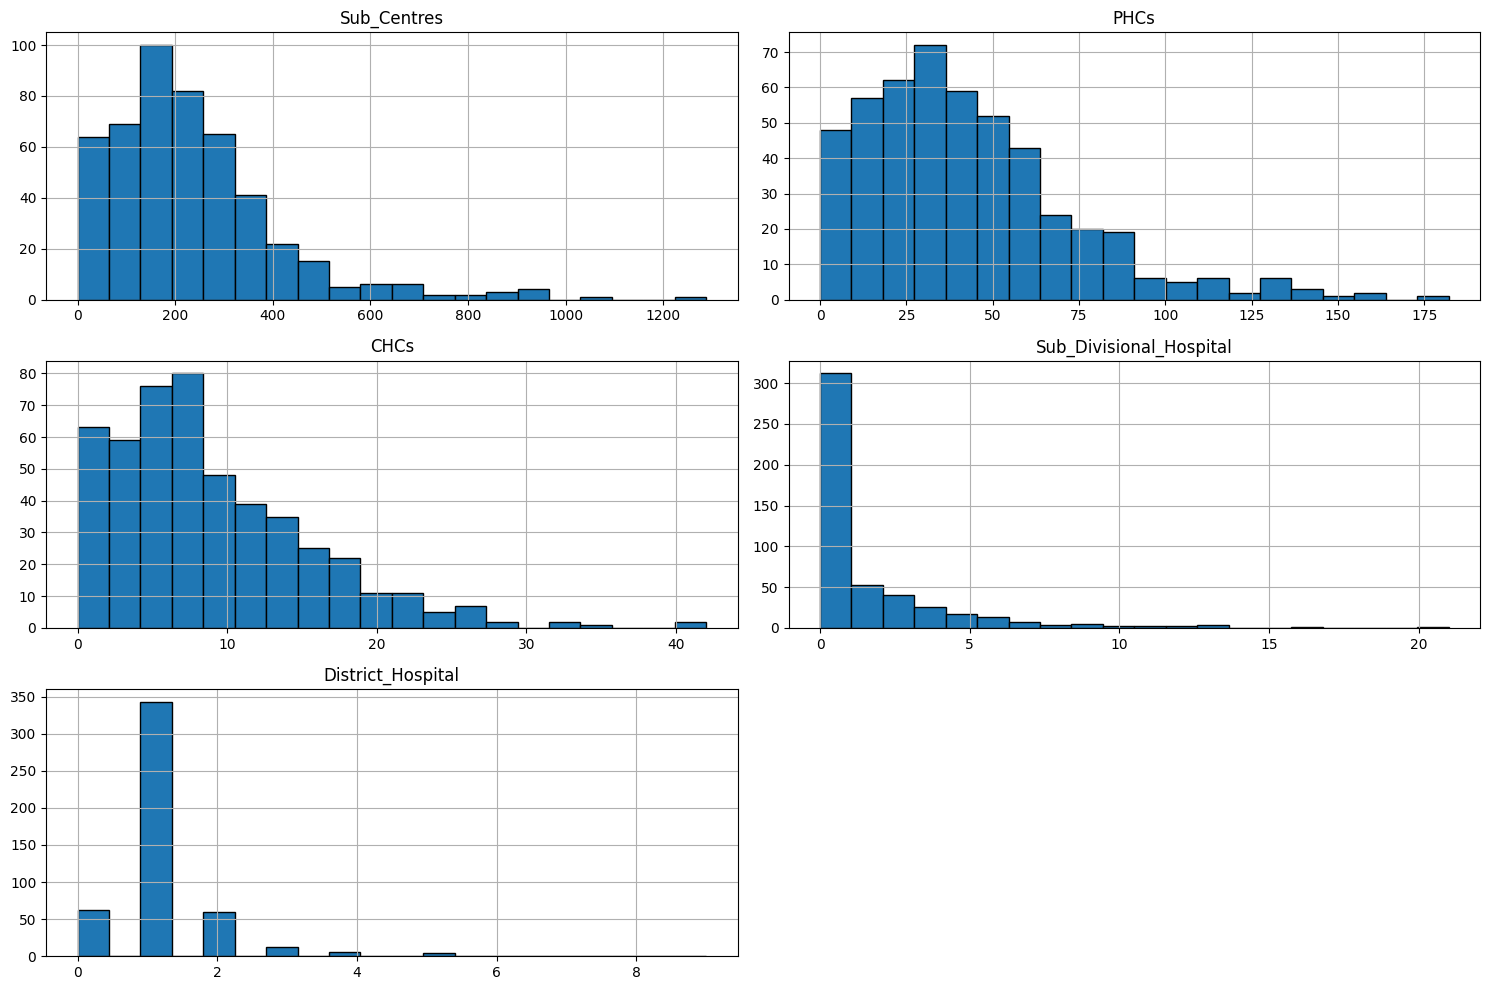

In [97]:
infrastructure_cols = [
    "Sub_Centres",
    "PHCs",
    "CHCs",
    "Sub_Divisional_Hospital",
    "District_Hospital"
]

merged_df[infrastructure_cols].hist(
    figsize=(15, 10),
    bins=20,
    edgecolor="black"
)

plt.tight_layout()
plt.show()

### Observations

- All five healthcare infrastructure variables exhibit positively skewed distributions, indicating that most districts possess relatively low to moderate levels of healthcare infrastructure, while a small number of districts have substantially higher infrastructure availability.

- The distributions of Sub Centres, PHCs, and CHCs show considerable variability across districts, reflecting unequal allocation of primary healthcare resources throughout the country.

- The number of Sub-Divisional Hospitals and District Hospitals is highly concentrated around one or fewer facilities per district. This is expected because these facilities are tertiary healthcare institutions and are considerably fewer in number compared to primary healthcare facilities.

- Several extreme observations are visible across the infrastructure variables, particularly for Sub Centres and PHCs. These districts are potential outliers and may represent either highly populated districts or administrative regions with comparatively larger healthcare networks.

- The observed skewness indicates that absolute infrastructure counts alone are insufficient for comparing districts. Consequently, population-normalized indicators such as Population per PHC and Population per CHC will be developed in subsequent analysis to facilitate meaningful comparisons.

##Distribution of Demographic Indicators

The demographic characteristics of districts were analysed using population, literacy, illiteracy, and household counts obtained from the Census of India 2011 dataset. These variables provide context for understanding the demand placed on healthcare infrastructure across districts.

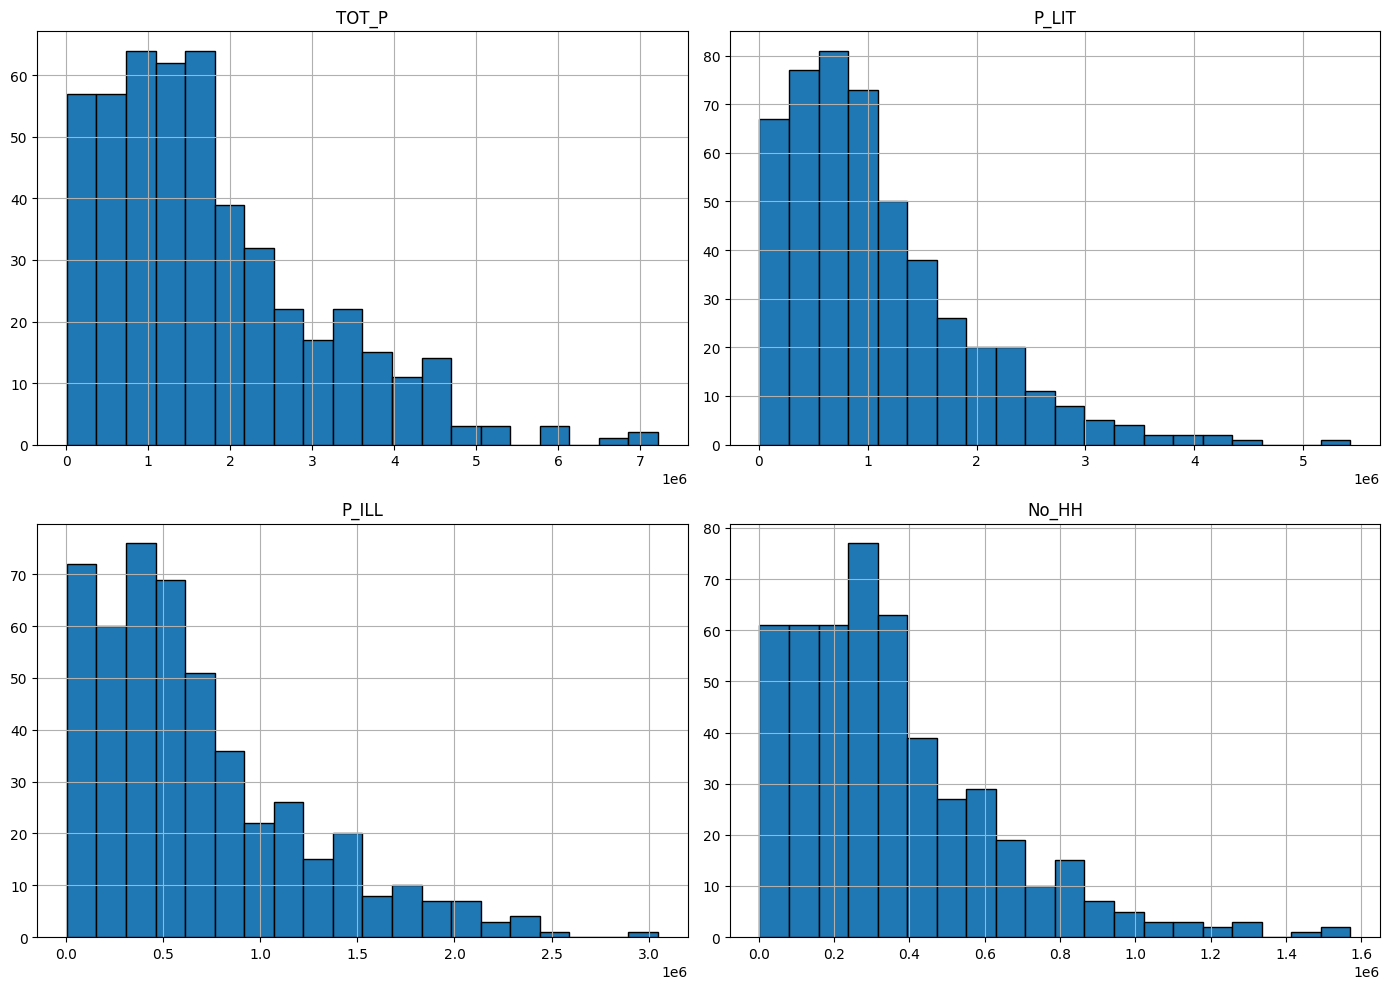

In [98]:
demographic_cols = [
    "TOT_P",
    "P_LIT",
    "P_ILL",
    "No_HH"
]

merged_df[demographic_cols].hist(
    figsize=(14, 10),
    bins=20,
    edgecolor="black"
)

plt.tight_layout()
plt.show()

### Observations

- All demographic variables exhibit positively skewed distributions, indicating that a relatively small number of districts account for a disproportionately large share of the population, households, and literacy counts.

- The Total Population distribution demonstrates substantial variation across districts, ranging from approximately 8,000 to over 7.2 million people. This highlights the importance of considering population size when evaluating healthcare infrastructure availability.

- The distributions of Literate Population and Illiterate Population closely follow the overall population distribution, suggesting that districts with larger populations also have correspondingly higher numbers of literate and illiterate individuals.

- Household counts also display considerable variability across districts, reflecting differences in district size and settlement patterns across India.

- The observed demographic heterogeneity indicates that direct comparison of healthcare facility counts may lead to misleading conclusions. Therefore, population-normalized healthcare indicators will be developed in subsequent analysis to enable equitable comparison across districts.

##Distribution of Health Indicators

The distribution of key public health indicators obtained from the National Family Health Survey (NFHS-5) was analysed to understand the variation in healthcare outcomes and service utilization across districts. These indicators provide insights into maternal and child health, healthcare accessibility, nutrition, and disease burden.

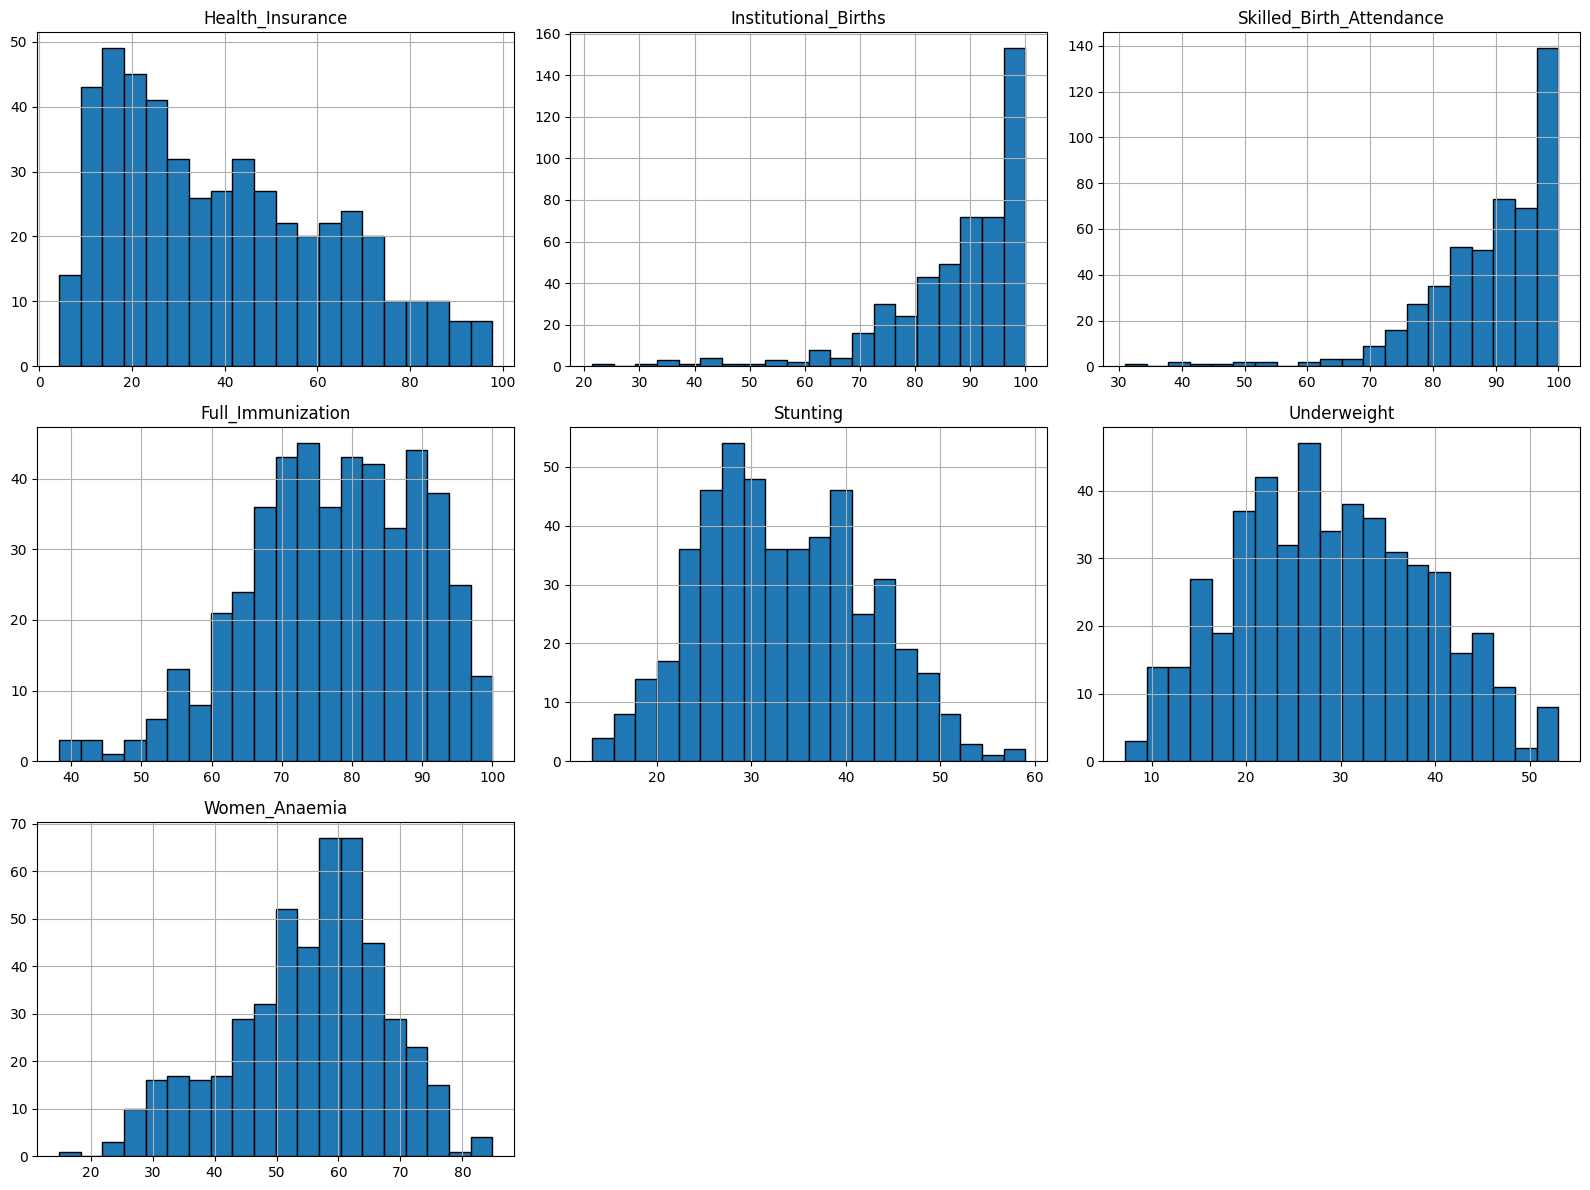

In [99]:
health_cols = [
    "Health_Insurance",
    "Institutional_Births",
    "Skilled_Birth_Attendance",
    "Full_Immunization",
    "Stunting",
    "Underweight",
    "Women_Anaemia"
]

merged_df[health_cols].hist(
    figsize=(16, 12),
    bins=20,
    edgecolor="black"
)

plt.tight_layout()
plt.show()

### Observations

- Health Insurance coverage exhibits substantial variability across districts, with values ranging from approximately 4% to 98%. This indicates considerable differences in financial protection against healthcare expenditure across India.

- Institutional Births and Skilled Birth Attendance are both concentrated towards higher percentages, with most districts reporting values above 80%. This suggests that maternal healthcare service utilization is relatively high in a majority of the analysed districts.

- Full Immunization also demonstrates relatively high coverage across districts, with most observations concentrated between 70% and 95%. Although a few districts report comparatively lower coverage, the overall distribution indicates satisfactory immunization performance in most regions.

- Nutritional indicators (Stunting and Underweight) display moderate variability across districts. While many districts have values clustered around the national average, a considerable number continue to report high levels of child malnutrition, highlighting persistent nutritional challenges.

- Women Anaemia remains consistently high across districts, with most observations concentrated between 45% and 70%. This indicates that anaemia continues to be a widespread public health concern despite improvements in several maternal and child health indicators.

- The contrasting distributions of healthcare service indicators (Institutional Births, Skilled Birth Attendance, and Full Immunization) and nutritional indicators (Stunting, Underweight, and Women Anaemia) suggest that improvements in healthcare service utilization do not necessarily translate into improved nutritional outcomes. This reinforces the need for a multidimensional assessment framework such as the proposed Healthcare Infrastructure Gap Index (HIGI).

##Correlation Analysis

Correlation analysis was performed to examine the linear relationships between healthcare infrastructure, demographic characteristics, and health outcome indicators. The objective is to identify variables that are strongly associated, detect potential multicollinearity, and provide evidence for feature selection in the development of the Healthcare Infrastructure Gap Index (HIGI) and subsequent predictive models.

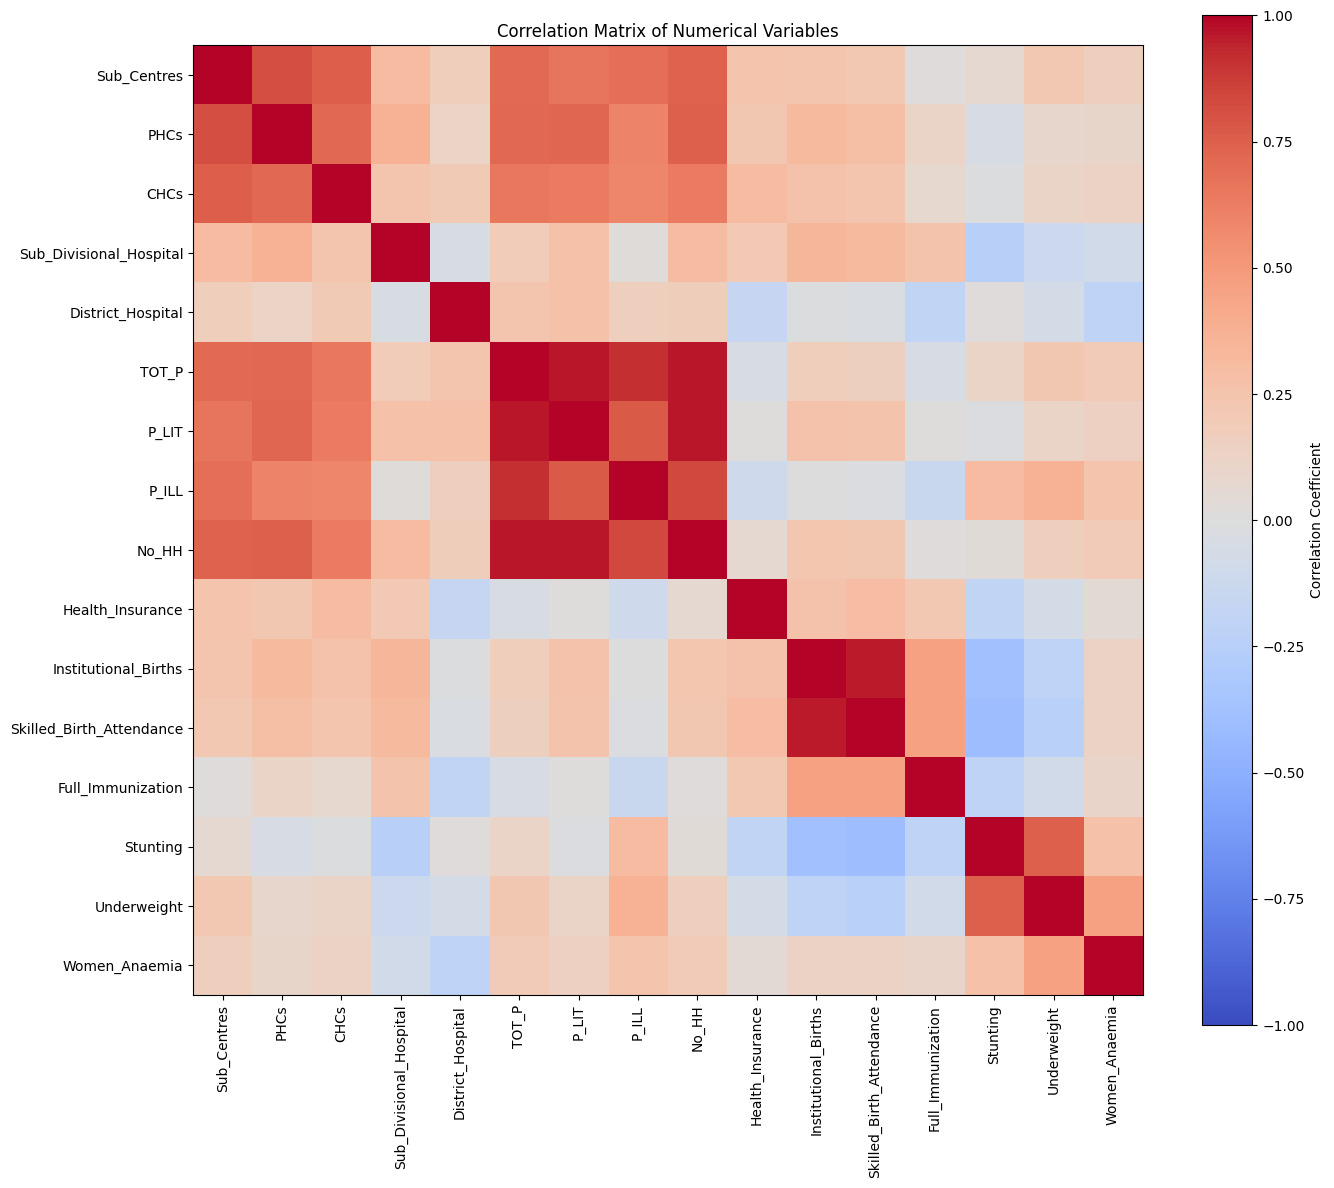

In [100]:
import matplotlib.pyplot as plt

corr = merged_df.select_dtypes(include=["int64", "float64"]).corr()
plt.figure(figsize=(14, 12))
im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar(im, label="Correlation Coefficient")
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

### Observations

- Strong positive correlations are observed among the healthcare infrastructure variables (Sub Centres, PHCs, and CHCs), indicating that districts with higher availability of one category of healthcare facility generally possess higher availability of other healthcare facilities as well.

- Population-related variables (Total Population, Literate Population, Illiterate Population, and Number of Households) exhibit very high positive correlations. This is expected, as larger districts naturally contain more households and larger literate and illiterate populations.

- Institutional Births and Skilled Birth Attendance demonstrate a strong positive relationship, suggesting that districts with greater institutional delivery rates also tend to have higher proportions of births attended by skilled healthcare professionals.

- Stunting and Underweight exhibit a strong positive correlation, reflecting the close relationship between these two indicators of child malnutrition.

- Institutional Births and Skilled Birth Attendance display negative correlations with Stunting and Underweight, indicating that districts with better maternal healthcare service utilization generally report lower levels of child malnutrition.

- Most infrastructure variables show only weak to moderate direct correlations with health outcome indicators. This suggests that healthcare outcomes are influenced by multiple socioeconomic and demographic factors in addition to infrastructure availability, supporting the need for a composite Healthcare Infrastructure Gap Index (HIGI).

##Preliminary Findings

Based on the exploratory data analysis, the following preliminary findings were identified:

1. Healthcare infrastructure is unevenly distributed across districts, with considerable variation in the availability of Sub Centres, PHCs, CHCs, and higher-level hospitals.

2. Population size varies substantially across districts, indicating that healthcare infrastructure should be evaluated relative to population rather than using absolute facility counts.

3. Maternal healthcare indicators, including Institutional Births and Skilled Birth Attendance, demonstrate consistently high coverage across most districts.

4. Health Insurance coverage varies considerably across districts, suggesting inequalities in financial access to healthcare services.

5. Child nutrition indicators (Stunting and Underweight) continue to indicate nutritional challenges in several districts.

6. Women Anaemia remains prevalent across a large proportion of districts and continues to represent an important public health concern.

7. Healthcare infrastructure variables exhibit strong positive relationships with one another, indicating that infrastructure development generally occurs across multiple facility types simultaneously.

8. Demographic variables are highly correlated, reflecting expected relationships between population, literacy, households, and settlement size.

9. Healthcare outcomes demonstrate stronger associations with one another than with infrastructure variables, indicating that healthcare outcomes are influenced by multiple demographic and socioeconomic factors.

10. The integrated analytical dataset provides a robust foundation for constructing the Healthcare Infrastructure Gap Index (HIGI) and developing predictive models during the final phase of the project.

# Next Steps

The work presented in this notebook establishes the analytical foundation for the remainder of the capstone project.

The next phase of the project will focus on:

- Developing population-normalized healthcare infrastructure indicators.
- Constructing the Healthcare Infrastructure Gap Index (HIGI).
- Identifying healthcare infrastructure patterns using clustering techniques.
- Developing predictive models to identify districts with significant healthcare infrastructure gaps.
- Interpreting model outcomes to generate data-driven recommendations for healthcare planning and resource allocation.

The integrated dataset developed in this notebook will be used directly in the modelling phase of the project.